In [2]:
import numpy as np
import matplotlib.pyplot as plt
import copy

import pyccl as ccl

import treecorr

import numpy as np
import matplotlib.pyplot as plt

import sys
import os
import copy

sys.path.append(os.path.abspath("/home/milan/Desktop/thesis/code")) 

In [3]:
from halo_model.power_spectra.matter_power_baryons import MatterPowerBaryons
from halo_model.halos.base.profile.profile import CompositeProfile

from halo_model.config.config import Config
from halo_model.algorithms.ridders_derivative import ridders_derivative

from halo_model.power_spectra.xi_computer import compute_Pk_2d, Pk_2d_to_Cl, Cl_to_xi, compute_xi, covariance_xi
from halo_model.power_spectra.del_xi import del_xi

sys.path.append(os.path.abspath("/home/milan/Desktop/thesis/code/plotting_code/constraining_power")) 

In [4]:
# set config 
cfg = Config()

cov = covariance_xi(cfg)
Cinv = np.linalg.inv(cov)

In [5]:

labels_map = {
    # WDM parameters
    'logM0': r"$\log M_0$",
    'beta': r"$\beta$",
    'logm0': r"$\log m_0$",
    
    # concentration 
    'Q': r"$Q_c$",
    'D': r"$Q_D$",
    
    # gas profile
    'logM_c': r"$\log M_c$",
    'theta_ej': r"$\theta_{\mathrm{eject}}$",
    'gamma': r"$\gamma$",
    'delta': r"$\delta$",
    'mu': r"$\mu$",
    'logM_gaslimit': r"$\log M_{\mathrm{gas,lim}}$",
    
    # stars
    'r_star': r"$r_\star$",
    'S': r"$S$",
}


In [6]:
# # Compute derivative for each theta angle

params = [
    # WDM parameters
    # ['logM0', 1],
    ['beta', 0.2],
    # ['logm0', 1],
    
    # concentration clumps
    ['Q', 0.4],
    
    # concentratiion distribution
    ['D', 0.4],   
    
    # gas profile
    ['logM_c', 1],
    ['theta_ej', 2],
    ['gamma', 0.8],
    ['delta', 3],
    ['mu', 0.2],
    # ['logM_gaslimit', 2], 
    
    # stellar profile
    # ['r_star', 0.005],
    # ['S', 0.4],
]



derivs_list = []
labels = []
fiducials = []

for param in params:
    name, h_init = param
    
    fname = f'derivs_{name}.npy'
    if os.path.exists(fname):
        print(f"Skipping {name}, {fname} already exists")
        derivs = np.load(fname, allow_pickle=True)
        
    else:
        print("Computing derivatives of parameter ", name)
        derivs = del_xi(cfg=cfg, param=name, h_init=h_init, n_iters=4)
        np.save(fname, derivs)
        
    derivs_list.append(derivs)
    labels.append(labels_map[name])
    fiducials.append(getattr(cfg, name))    
    

D = np.array(derivs_list)

Skipping beta, derivs_beta.npy already exists
Skipping Q, derivs_Q.npy already exists
Skipping D, derivs_D.npy already exists
Skipping logM_c, derivs_logM_c.npy already exists
Skipping theta_ej, derivs_theta_ej.npy already exists
Skipping gamma, derivs_gamma.npy already exists
Skipping delta, derivs_delta.npy already exists
Skipping mu, derivs_mu.npy already exists


In [12]:
prior_map = {
    # WDM parameters
    'logM0': 100,
    'beta': 100,
    'logm0': 100,
    
    # concentration
    'Q': 0.5,
    'D': 0.3,
    
    # gas profile
    'logM_c': 0.2,
    'theta_ej': 1,
    'mu': 0.2,
    'gamma': 1,
    'delta': 2,
    'logM_gaslimit': 5,
    
    # stars
    'r_star': 0.005,
    'S': 1,
}

priors = np.diag([1.0 / prior_map[param[0]]**2 for param in params])
prior_sigmas = [prior_map[param[0]] for param in params]

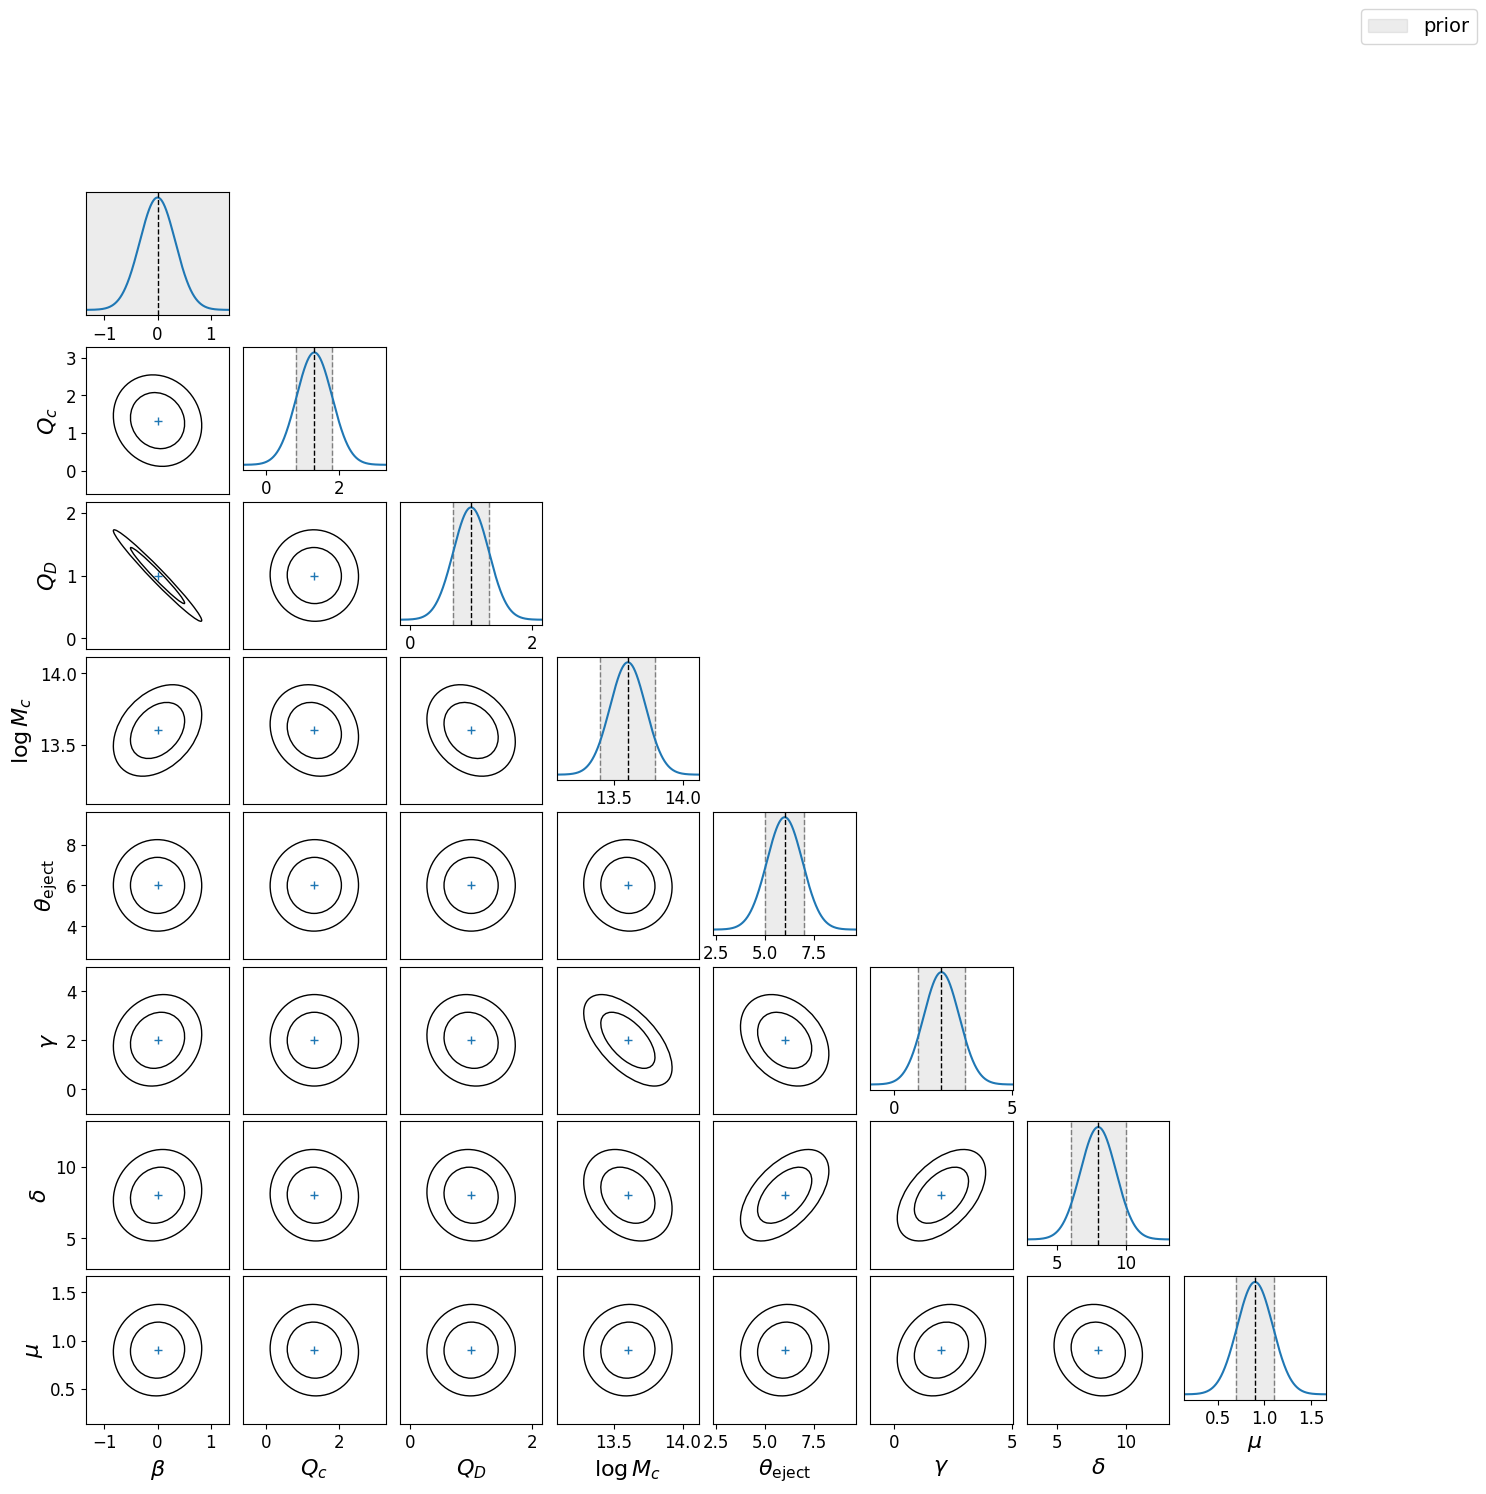

In [13]:
from fisher_corner import fisher_corner

F = D @ Cinv @ D.T + priors

plt.rcParams.update({
    "font.size": 16,          # base font size
    "axes.labelsize": 16,     # x and y labels
    "axes.titlesize": 16,     # title
    "legend.fontsize": 14,    # legend
    "xtick.labelsize": 12,    # x tick labels
    "ytick.labelsize": 12,    # y tick labels
})

fig = fisher_corner(F, fiducials, labels=labels, prior_sigmas=prior_sigmas)
plt.savefig("constraining_power_narrow_prior.pdf", dpi=300, bbox_inches='tight')
plt.show()